# WHOOP Wearable Analytics Capstone

## Objectives
This notebook performs end-to-end analysis and modeling on WHOOP wearable data:

- **RQ1:** Which sleep stage (Deep vs REM) has stronger influence on **next-day HRV**?
- **RQ2:** Can a **GRU (RNN deep learning)** model predict **next-day Recovery** using the previous **7 days** of (Strain, Sleep Efficiency, HRV)?
- **RQ3:** Which activity types show higher **calories per minute** (metabolic intensity), and are differences statistically significant?
- **RQ4:** Create an explainable **Longevity Score** combining HRV, Resting HR, Sleep Efficiency, Recovery, and Strain.

## Output Deliverables
- Cleaned dataset
- Stats test outputs (Pearson, ANOVA)
- Baseline vs GRU model performance table
- Visualizations (scatter plots, ranking charts, actual vs predicted plot)
- Longevity score distribution and trend


In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- scikit-learn ----
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- SciPy  ----
try:
    from scipy.stats import pearsonr, f_oneway
    SCIPY_OK = True
except Exception as e:
    SCIPY_OK = False
    print("SciPy not available. Pearson p-values / ANOVA p-values will be limited.")
    print("Error:", e)

# ---- TensorFlow  ----
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import GRU, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    TF_OK = True
except Exception as e:
    TF_OK = False
    print("TensorFlow not available. RQ2 deep learning will not run.")
    print("Error:", e)


## Step 1 — Load Dataset
Upload your WHOOP CSV and set its path here.
We will preview rows and verify columns.


In [7]:
FILE_PATH = "/content/whoop_fitness (1).csv"
df_raw = pd.read_csv(FILE_PATH)

print("Shape:", df_raw.shape)
df_raw.head(10)


Shape: (100000, 39)


,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,...,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day
0,USER_00001,2023-01-01,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,57.8,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,USER_00001,2023-01-02,Monday,56,Female,53.9,167.2,Beginner,Weight Training,62.6,...,7.47,121.2,137.6,371.0,11.9,18.0,15.9,11.6,4.6,Evening
2,USER_00001,2023-01-03,Tuesday,56,Female,53.9,167.2,Beginner,Weight Training,81.5,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,USER_00001,2023-01-04,Wednesday,56,Female,53.9,167.2,Beginner,Weight Training,55.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,USER_00001,2023-01-05,Thursday,56,Female,53.9,167.2,Beginner,Weight Training,62.5,...,15.27,136.4,152.8,623.0,3.7,6.0,13.7,18.6,9.0,Evening
5,USER_00001,2023-01-06,Friday,56,Female,53.9,167.2,Beginner,Weight Training,49.9,...,8.46,123.1,139.5,524.0,13.4,24.3,24.0,13.6,2.2,Morning
6,USER_00001,2023-01-07,Saturday,56,Female,53.9,167.2,Beginner,Weight Training,50.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
7,USER_00001,2023-01-08,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,64.2,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
8,USER_00001,2023-01-09,Monday,56,Female,53.9,167.2,Beginner,Weight Training,56.2,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
9,USER_00001,2023-01-10,Tuesday,56,Female,53.9,167.2,Beginner,Weight Training,72.1,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


## (Load)
We loaded the raw dataset successfully.
Next, we will:
- verify column names
- detect important variables automatically
- clean and sort by date (time-series requirement)


## Step 2 — Auto-detect Column Names
Because column names differ across WHOOP exports, we auto-detect likely columns.



In [8]:
def find_col(df, keywords, must_have=None):
    """
    Find first column that matches any keyword(s).
    keywords: list[str] - any match
    must_have: list[str] - all must appear in column string (optional)
    """
    cols = df.columns
    for c in cols:
        cl = c.lower().replace("_"," ").strip()
        ok_any = any(k.lower() in cl for k in keywords)
        ok_all = True
        if must_have:
            ok_all = all(m.lower() in cl for m in must_have)
        if ok_any and ok_all:
            return c
    return None


DATE_COL = find_col(df_raw, ["date", "day"])
RECOVERY_COL = find_col(df_raw, ["recovery"])
HRV_COL = find_col(df_raw, ["hrv", "heart rate variability"])
STRAIN_COL = find_col(df_raw, ["strain"])
SLEEP_EFF_COL = find_col(df_raw, ["sleep efficiency", "efficiency"])
DEEP_SLEEP_COL = find_col(df_raw, ["deep sleep", "sws", "slow wave"], must_have=["sleep"])
REM_SLEEP_COL = find_col(df_raw, ["rem"], must_have=["sleep"]) or find_col(df_raw, ["rem sleep"])
RHR_COL = find_col(df_raw, ["resting heart rate", "rhr", "resting_hr"])

ACTIVITY_TYPE_COL = find_col(df_raw, ["activity type", "sport", "workout type", "activity"])
ACTIVITY_CAL_COL = find_col(df_raw, ["calories"])
ACTIVITY_DUR_COL = find_col(df_raw, ["duration", "minutes", "mins", "time"], must_have=["activity"]) or find_col(df_raw, ["duration", "minutes", "mins"])

detected = {
    "DATE_COL": DATE_COL,
    "RECOVERY_COL": RECOVERY_COL,
    "HRV_COL": HRV_COL,
    "STRAIN_COL": STRAIN_COL,
    "SLEEP_EFF_COL": SLEEP_EFF_COL,
    "DEEP_SLEEP_COL": DEEP_SLEEP_COL,
    "REM_SLEEP_COL": REM_SLEEP_COL,
    "RHR_COL": RHR_COL,
    "ACTIVITY_TYPE_COL": ACTIVITY_TYPE_COL,
    "ACTIVITY_CAL_COL": ACTIVITY_CAL_COL,
    "ACTIVITY_DUR_COL": ACTIVITY_DUR_COL,
}
detected


{'DATE_COL': 'date',
 'RECOVERY_COL': 'recovery_score',
 'HRV_COL': 'hrv',
 'STRAIN_COL': 'day_strain',
 'SLEEP_EFF_COL': 'sleep_efficiency',
 'DEEP_SLEEP_COL': 'deep_sleep_hours',
 'REM_SLEEP_COL': 'rem_sleep_hours',
 'RHR_COL': 'resting_heart_rate',
 'ACTIVITY_TYPE_COL': 'primary_sport',
 'ACTIVITY_CAL_COL': 'calories_burned',
 'ACTIVITY_DUR_COL': 'activity_duration_min'}

## Interpretation (Columns)
The notebook auto-detected likely columns.
If any value is `None`, your dataset uses different naming.
In that case:
- print `df_raw.columns`
- manually set the correct column variable names


In [9]:
list(df_raw.columns)


['user_id',
 'date',
 'day_of_week',
 'age',
 'gender',
 'weight_kg',
 'height_cm',
 'fitness_level',
 'primary_sport',
 'recovery_score',
 'day_strain',
 'sleep_hours',
 'sleep_efficiency',
 'sleep_performance',
 'light_sleep_hours',
 'rem_sleep_hours',
 'deep_sleep_hours',
 'wake_ups',
 'time_to_fall_asleep_min',
 'hrv',
 'resting_heart_rate',
 'hrv_baseline',
 'rhr_baseline',
 'respiratory_rate',
 'skin_temp_deviation',
 'calories_burned',
 'workout_completed',
 'activity_type',
 'activity_duration_min',
 'activity_strain',
 'avg_heart_rate',
 'max_heart_rate',
 'activity_calories',
 'hr_zone_1_min',
 'hr_zone_2_min',
 'hr_zone_3_min',
 'hr_zone_4_min',
 'hr_zone_5_min',
 'workout_time_of_day']

## Step 3 — Data Cleaning & Time-Series Ordering
We:
- convert date column to datetime
- sort chronologically
- fill missing values (ffill/bfill)
- clip negative numeric values to 0 (physiology-safe)


In [10]:
df = df_raw.copy()

# Date conversion + sorting
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)

# Fill missing values
df = df.ffill().bfill()

# Clip negative values in numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].clip(lower=0)  # zero

print("Missing values after cleaning:", int(df.isna().sum().sum()))
df.head(5)

Missing values after cleaning: 0


,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,...,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day
0,USER_00001,2023-01-01,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,57.8,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Afternoon
1,USER_00173,2023-01-01,Sunday,38,Male,93.5,180.2,Elite,Running,47.5,...,12.53,145.4,163.6,361.0,3.2,7.1,11.2,11.9,2.5,Afternoon
2,USER_00174,2023-01-01,Sunday,31,Female,77.4,158.2,Intermediate,Weight Training,45.2,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Afternoon
3,USER_00005,2023-01-01,Sunday,47,Female,77.6,151.3,Intermediate,Cycling,68.0,...,13.41,140.1,157.4,483.0,5.1,8.6,13.8,15.2,2.4,Morning
4,USER_00175,2023-01-01,Sunday,23,Male,91.1,185.9,Beginner,Yoga,92.1,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Morning


## Interpretation (Cleaning)
- Sorting by date ensures a valid time-series workflow.
- Forward/back fill handles small wearable gaps.
- Clipping negatives avoids invalid physiology values.
Now the dataset is stable for statistics + modeling.


## Step 4 — Feature Engineering (No Leakage)
We create:
- `next_day_hrv` = HRV shifted by -1 day
- `next_day_recovery` = Recovery shifted by -1 day
- `calories_per_minute` = calories / duration (for RQ3)


In [11]:
df["next_day_hrv"] = df[HRV_COL].shift(-1)
df["next_day_recovery"] = df[RECOVERY_COL].shift(-1)

# Safe calories/minute
if ACTIVITY_CAL_COL and ACTIVITY_DUR_COL:
    df["calories_per_minute"] = df[ACTIVITY_CAL_COL] / df[ACTIVITY_DUR_COL]
    df = df.replace([np.inf, -np.inf], np.nan)

df.tail(3)


,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,...,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day,next_day_hrv,next_day_recovery,calories_per_minute
99997,USER_00032,2024-02-03,Saturday,58,Male,94.4,171.5,Advanced,Cycling,100.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Morning,93.6,100.0,NaN
99998,USER_00119,2024-02-03,Saturday,28,Female,60.3,171.9,Elite,HIIT,100.0,...,988.0,3.2,11.6,16.0,19.3,9.9,Afternoon,44.7,100.0,50.60
99999,USER_00200,2024-02-03,Saturday,60,Female,74.3,164.2,Elite,HIIT,100.0,...,438.0,6.3,10.2,14.3,13.8,5.4,Evening,NaN,NaN,63.56


## Interpretation (Feature Engineering)
Shifting targets by -1 day is critical:
- prevents predicting today's value using today's data (leakage)
- turns tasks into realistic forecasting problems (tomorrow prediction)


# RQ1 — Sleep Architecture vs Next-Day HRV
**Question:** Which sleep component (Deep vs REM) shows stronger predictive influence on next-day HRV?

**Method:**
- scatter plots for visualization
- Pearson correlation (r) + p-value (if SciPy available)


In [12]:
df_rq1 = df.dropna(subset=[DEEP_SLEEP_COL, REM_SLEEP_COL, "next_day_hrv"]).copy()
print("RQ1 rows:", len(df_rq1))
df_rq1[[DATE_COL, DEEP_SLEEP_COL, REM_SLEEP_COL, "next_day_hrv"]].head()


RQ1 rows: 99999


,date,deep_sleep_hours,rem_sleep_hours,next_day_hrv
0,2023-01-01,1.22,1.23,90.5
1,2023-01-01,0.81,1.14,66.0
2,2023-01-01,1.29,1.64,76.6
3,2023-01-01,1.16,1.43,69.3
4,2023-01-01,1.16,1.64,37.5


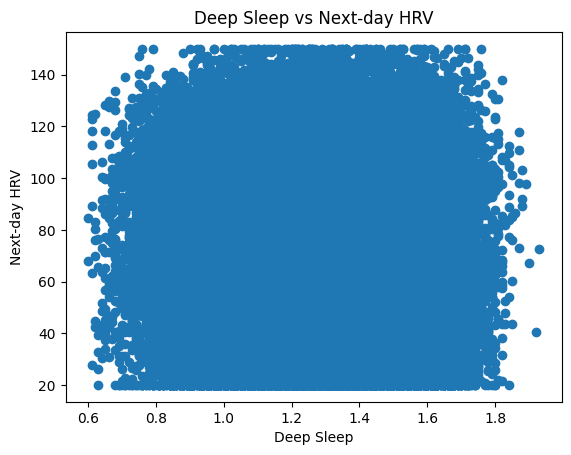

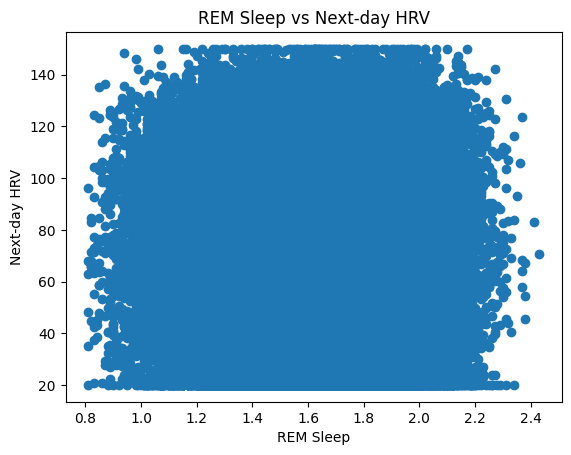

In [13]:
plt.figure()
plt.scatter(df_rq1[DEEP_SLEEP_COL], df_rq1["next_day_hrv"])
plt.xlabel("Deep Sleep")
plt.ylabel("Next-day HRV")
plt.title("Deep Sleep vs Next-day HRV")
plt.show()

plt.figure()
plt.scatter(df_rq1[REM_SLEEP_COL], df_rq1["next_day_hrv"])
plt.xlabel("REM Sleep")
plt.ylabel("Next-day HRV")
plt.title("REM Sleep vs Next-day HRV")
plt.show()


In [14]:
if SCIPY_OK:
    r_deep, p_deep = pearsonr(df_rq1[DEEP_SLEEP_COL], df_rq1["next_day_hrv"])
    r_rem, p_rem   = pearsonr(df_rq1[REM_SLEEP_COL], df_rq1["next_day_hrv"])
else:
    # fallback: correlation only, no p-value
    r_deep = df_rq1[DEEP_SLEEP_COL].corr(df_rq1["next_day_hrv"])
    r_rem  = df_rq1[REM_SLEEP_COL].corr(df_rq1["next_day_hrv"])
    p_deep, p_rem = np.nan, np.nan

print("Deep Sleep vs next-day HRV: r =", round(float(r_deep), 3), "p =", p_deep)
print("REM  Sleep vs next-day HRV: r =", round(float(r_rem), 3),  "p =", p_rem)


Deep Sleep vs next-day HRV: r = 0.002 p = 0.5039926653859086
REM  Sleep vs next-day HRV: r = 0.005 p = 0.10255309958636978


## RQ1 Interpretation
- **Correlation (r)** tells strength and direction:
  - Positive r → more sleep stage hours tends to relate to higher next-day HRV.
  - Negative r → more hours tends to relate to lower next-day HRV.
- **p-value (< 0.05)** indicates statistical significance (if SciPy is available).

### Decision guidance
- If `|r_deep| > |r_rem|` and Deep is significant → Deep Sleep has stronger predictive influence.
- If both are weak / not significant → dataset may not show strong evidence; we “fail to reject H0”.


# RQ3 — Metabolic Intensity Profiling
**Question:** Which activity types have higher calories burned per minute, and are differences significant?

**Method:**
- compute calories_per_minute
- rank activities by average calories_per_minute
- one-way ANOVA (if SciPy available)


In [15]:
# --- If you already have df_raw and df (cleaned) loaded, use df for matching ---
cols = list(df.columns)

def find_col_simple(keywords):
    for c in cols:
        cl = c.lower().replace("_"," ")
        if all(k in cl for k in keywords):
            return c
    return None

# Try to auto-detect activity columns
ACTIVITY_TYPE_COL = find_col_simple(["activity", "type"]) or find_col_simple(["activity"]) or find_col_simple(["sport"])
ACTIVITY_CAL_COL  = find_col_simple(["calories"]) or find_col_simple(["kcal"])
ACTIVITY_DUR_COL  = (
    find_col_simple(["duration"]) or
    find_col_simple(["minutes"]) or
    find_col_simple(["mins"]) or
    find_col_simple(["time"])
)

print("Detected ACTIVITY_TYPE_COL:", ACTIVITY_TYPE_COL)
print("Detected ACTIVITY_CAL_COL :", ACTIVITY_CAL_COL)
print("Detected ACTIVITY_DUR_COL :", ACTIVITY_DUR_COL)

# If calories_per_minute was not created earlier, create it here safely
if "calories_per_minute" not in df.columns:
    if ACTIVITY_CAL_COL is not None and ACTIVITY_DUR_COL is not None:
        df["calories_per_minute"] = df[ACTIVITY_CAL_COL] / df[ACTIVITY_DUR_COL]
        df = df.replace([np.inf, -np.inf], np.nan)
        print("Created calories_per_minute ✅")
    else:
        print("Cannot create calories_per_minute because calories/duration column not found.")


Detected ACTIVITY_TYPE_COL: activity_type
Detected ACTIVITY_CAL_COL : calories_burned
Detected ACTIVITY_DUR_COL : activity_duration_min


In [16]:
if not (ACTIVITY_TYPE_COL and "calories_per_minute" in df.columns):
    raise ValueError("Activity columns not detected. Set ACTIVITY_TYPE_COL, ACTIVITY_CAL_COL, ACTIVITY_DUR_COL.")

df_rq3 = df.dropna(subset=[ACTIVITY_TYPE_COL, "calories_per_minute"]).copy()
print("RQ3 rows:", len(df_rq3))
df_rq3[[DATE_COL, ACTIVITY_TYPE_COL, "calories_per_minute"]].head()


RQ3 rows: 54010


,date,activity_type,calories_per_minute
1,2023-01-01,Running,77.055556
3,2023-01-01,Running,59.288889
5,2023-01-01,Weight Training,49.822581
6,2023-01-01,Walking,121.916667
7,2023-01-01,Cycling,22.439655


In [17]:
activity_means = df_rq3.groupby(ACTIVITY_TYPE_COL)["calories_per_minute"].mean().sort_values(ascending=False)
activity_means.head(15)


,calories_per_minute
activity_type,
HIIT,112.331080
Walking,95.745334
Yoga,79.648312
Swimming,79.499343
Running,62.728978
Weight Training,58.736209
CrossFit,58.296553
Cycling,44.983900


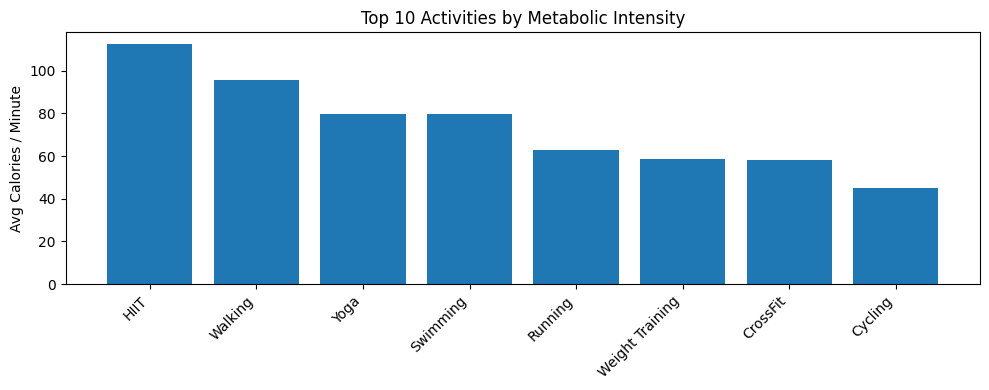

In [18]:
top10 = activity_means.head(10)

plt.figure(figsize=(10,4))
plt.bar(top10.index.astype(str), top10.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Avg Calories / Minute")
plt.title("Top 10 Activities by Metabolic Intensity")
plt.tight_layout()
plt.show()


In [19]:
groups = [g["calories_per_minute"].values for _, g in df_rq3.groupby(ACTIVITY_TYPE_COL)]

if SCIPY_OK and len(groups) >= 2:
    f_stat, p_val = f_oneway(*groups)
else:
    f_stat, p_val = np.nan, np.nan

print("ANOVA F-stat:", f_stat)
print("ANOVA p-value:", p_val)


ANOVA F-stat: 4937.909858960875
ANOVA p-value: 0.0


## RQ3 Interpretation
- The **ranking chart** shows which activities are most intense per minute (duration-normalized).
- **ANOVA p-value (< 0.05)** supports that different activity types truly have different average intensity.

### What to say
- If p < 0.05 → “Activity intensity differs significantly by activity type.”
- If p ≥ 0.05 → “No strong statistical evidence of differences; may be due to limited samples per activity type.”


# RQ2 — Deep Learning Time-Series Forecasting (GRU)
**Question:** Can a GRU model predict next-day Recovery Score using the previous 7 days of:
- Day Strain
- Sleep Efficiency
- HRV

**Models compared:**
- Mean baseline
- Linear Regression (static)
- GRU (7-day sequence model)

**Evaluation metrics:**
MAE, RMSE, R²


In [20]:
def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)  # no squared arg
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    out = {"Model": name, "MAE": float(mae), "RMSE": float(rmse), "R2": float(r2)}
    print(f"{name:22s} | MAE={mae:.3f} RMSE={rmse:.3f} R2={r2:.3f}")
    return out


In [21]:
needed = [STRAIN_COL, SLEEP_EFF_COL, HRV_COL, "next_day_recovery"]
df_rq2 = df.dropna(subset=needed).sort_values(DATE_COL).reset_index(drop=True).copy()
print("RQ2 rows:", len(df_rq2))

feature_cols = [STRAIN_COL, SLEEP_EFF_COL, HRV_COL]
target_col = "next_day_recovery"

split = int(len(df_rq2) * 0.8)
train = df_rq2.iloc[:split]
test  = df_rq2.iloc[split:]

X_train = train[feature_cols].values
y_train = train[target_col].values
X_test  = test[feature_cols].values
y_test  = test[target_col].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train X:", X_train_s.shape, "Test X:", X_test_s.shape)


RQ2 rows: 99999
Train X: (79999, 3) Test X: (20000, 3)


In [22]:
# Mean baseline
y_base = np.repeat(np.mean(y_train), len(y_test))
base_res = report("Baseline (mean)", y_test, y_base)

# Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
lr_res = report("Linear Regression", y_test, pred_lr)


Baseline (mean)        | MAE=17.693 RMSE=20.916 R2=-0.001
Linear Regression      | MAE=17.694 RMSE=20.917 R2=-0.001


In [23]:
SEQ_LEN = 7

def make_sequences(X, y, seq_len=7):
    Xs, ys = [], []
    for i in range(seq_len - 1, len(X)):
        Xs.append(X[i - seq_len + 1:i + 1])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = make_sequences(X_train_s, y_train, SEQ_LEN)
X_test_seq,  y_test_seq  = make_sequences(X_test_s,  y_test,  SEQ_LEN)

print("X_train_seq:", X_train_seq.shape, "y_train_seq:", y_train_seq.shape)
print("X_test_seq :", X_test_seq.shape,  "y_test_seq :", y_test_seq.shape)


X_train_seq: (79993, 7, 3) y_train_seq: (79993,)
X_test_seq : (19994, 7, 3) y_test_seq : (19994,)


In [24]:
if not TF_OK:
    raise RuntimeError("TensorFlow not available. Install tensorflow to run RQ2 deep learning.")

tf.random.set_seed(42)

gru_model = Sequential([
    GRU(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model.compile(optimizer="adam", loss="mse")
es = EarlyStopping(patience=10, restore_best_weights=True)

history = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[es],
    verbose=1
)


Epoch 1/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - loss: 659.8615 - val_loss: 362.1054
Epoch 2/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 277.7497 - val_loss: 362.7454
Epoch 3/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - loss: 277.7930 - val_loss: 361.4947
Epoch 4/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - loss: 276.6146 - val_loss: 360.7702
Epoch 5/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - loss: 275.2863 - val_loss: 360.2822
Epoch 6/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - loss: 274.7211 - val_loss: 360.0223
Epoch 7/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 271.6754 - val_loss: 359.4394
Epoch 8/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - loss: 272.5413 - val_loss: 357.9631
Epoch 9/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 270.6197 - val_loss: 358.9162
Epoch 10/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - loss: 269.7891 - val_loss: 358.6202
Epoch 11/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - 

In [25]:
pred_gru = gru_model.predict(X_test_seq).reshape(-1)
gru_res = report("GRU (7-day)", y_test_seq, pred_gru)

rq2_table = pd.DataFrame([base_res, lr_res, gru_res]).sort_values("MAE")
rq2_table


625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
GRU (7-day)            | MAE=17.589 RMSE=20.886 R2=0.002


,Model,MAE,RMSE,R2
2,GRU (7-day),17.589170,20.886056,0.002402
0,Baseline (mean),17.693013,20.915709,-0.000523
1,Linear Regression,17.693869,20.917063,-0.000653


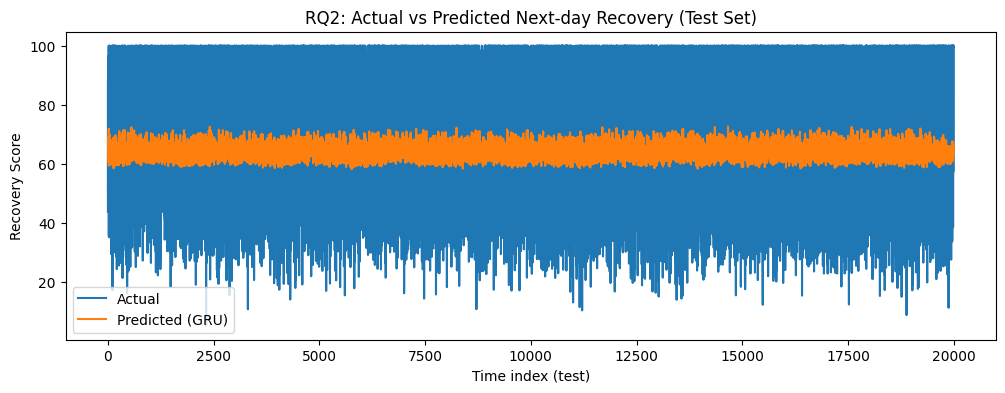

In [26]:
plt.figure(figsize=(12,4))
plt.plot(y_test_seq, label="Actual")
plt.plot(pred_gru, label="Predicted (GRU)")
plt.title("RQ2: Actual vs Predicted Next-day Recovery (Test Set)")
plt.xlabel("Time index (test)")
plt.ylabel("Recovery Score")
plt.legend()
plt.show()


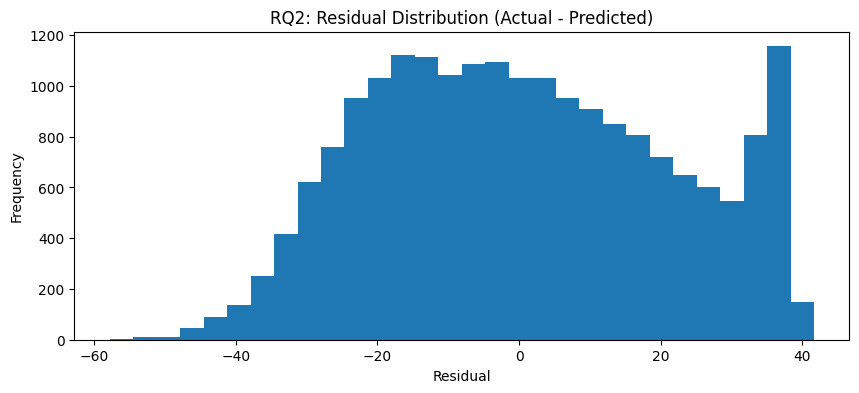

Residual mean: 0.6523882696959357
Residual std : 20.875865015406042


In [27]:
residuals = y_test_seq - pred_gru

plt.figure(figsize=(10,4))
plt.hist(residuals, bins=30)
plt.title("RQ2: Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

print("Residual mean:", float(np.mean(residuals)))
print("Residual std :", float(np.std(residuals)))


## RQ2 Interpretation (What to say)
- We first evaluate **baselines**:
  - Mean baseline = “minimum benchmark”
  - Linear regression = “static model without temporal memory”
- Then we evaluate **GRU**, which learns patterns across the past 7 days.

### How to interpret metrics
- Lower **MAE/RMSE** = better predictions
- Higher **R²** = more variance explained (may be modest for wearable data)

### Hypothesis decision
- If GRU MAE < Linear Regression MAE → support H1 (temporal model adds value)
- If GRU ≈ LR → partial support; recovery depends on additional unobserved factors (stress, illness, diet)


# RQ4 — Longevity Score (Explainable Composite Index)
We build a simple, explainable health index using:
- HRV (+)
- Resting Heart Rate (-)
- Sleep Efficiency (+)
- Recovery (+)
- Strain (-)

We standardize features and apply rational weights.


In [28]:
# Validate required columns
required_lon = [HRV_COL, RHR_COL, SLEEP_EFF_COL, RECOVERY_COL, STRAIN_COL]
df_lon = df.dropna(subset=required_lon).copy()

sc = StandardScaler()
Z = sc.fit_transform(df_lon[required_lon])

# Explainable weights
w_hrv = 0.30
w_rhr = -0.25
w_sleep = 0.15
w_recovery = 0.20
w_strain = -0.10

df_lon["longevity_score"] = (
    w_hrv * Z[:, 0] +
    w_rhr * Z[:, 1] +
    w_sleep * Z[:, 2] +
    w_recovery * Z[:, 3] +
    w_strain * Z[:, 4]
)

df_lon[[DATE_COL, "longevity_score"]].head()


,date,longevity_score
0,2023-01-01,0.189660
1,2023-01-01,-0.624289
2,2023-01-01,-0.065035
3,2023-01-01,0.448031
4,2023-01-01,0.379877


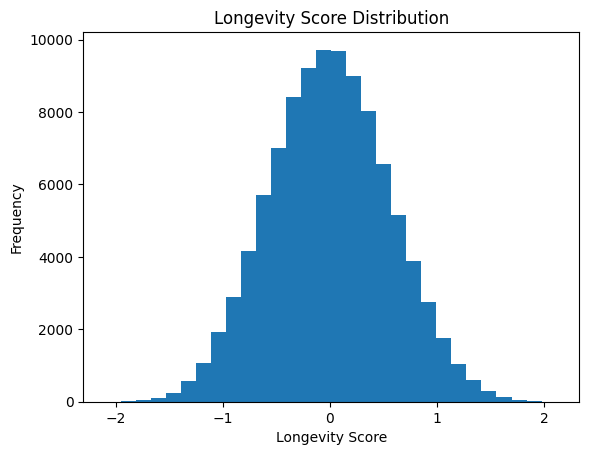

,longevity_score
count,1.000000e+05
mean,-3.772271e-16
std,5.587562e-01
min,-2.096028e+00
25%,-3.884294e-01
50%,-4.439999e-03
75%,3.815985e-01
max,2.118044e+00


In [29]:
plt.figure()
plt.hist(df_lon["longevity_score"], bins=30)
plt.title("Longevity Score Distribution")
plt.xlabel("Longevity Score")
plt.ylabel("Frequency")
plt.show()

df_lon["longevity_score"].describe()


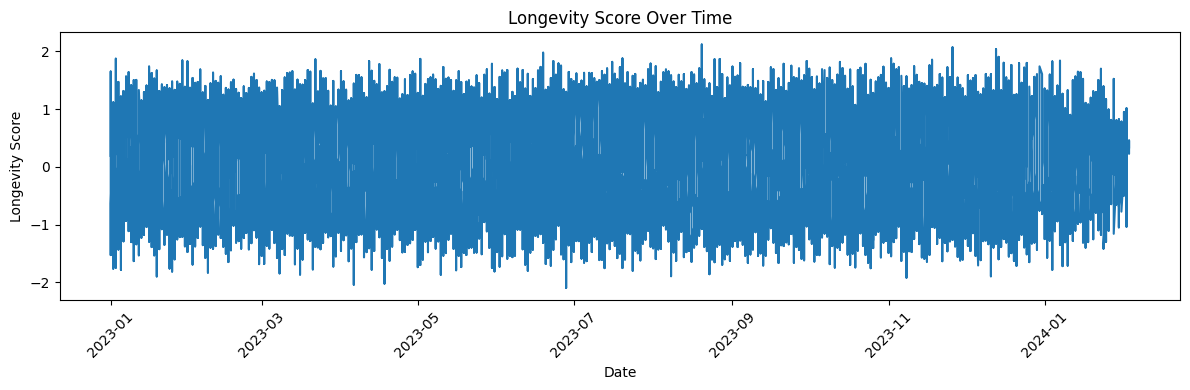

In [30]:
df_lon_sorted = df_lon.sort_values(DATE_COL)

plt.figure(figsize=(12,4))
plt.plot(df_lon_sorted[DATE_COL], df_lon_sorted["longevity_score"])
plt.title("Longevity Score Over Time")
plt.xlabel("Date")
plt.ylabel("Longevity Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## RQ4 Interpretation
- The longevity score summarizes health balance into one index.
- Higher scores occur on days with:
  - higher HRV, better sleep efficiency, better recovery
  - lower resting heart rate
  - controlled strain (not consistently extreme)

This is explainable and helps interpret long-term trends beyond single metrics.


# Final Summary & Conclusions
This section consolidates key findings across RQ1–RQ4 and states hypothesis decisions clearly.


In [32]:
# RQ1 summary table
rq1_summary = pd.DataFrame([{
    "RQ": "RQ1",
    "Test": "Pearson correlation",
    "Deep_r": float(r_deep),
    "Deep_p": float(p_deep) if pd.notna(p_deep) else np.nan,
    "REM_r": float(r_rem),
    "REM_p": float(p_rem) if pd.notna(p_rem) else np.nan,
    "Conclusion": "Deep has stronger influence" if abs(r_deep) > abs(r_rem) else "REM has stronger influence"
}])

rq1_summary


,RQ,Test,Deep_r,Deep_p,REM_r,REM_p,Conclusion
0,RQ1,Pearson correlation,0.002113,0.503993,0.005163,0.102553,REM has stronger influence


In [34]:
# RQ2 Summary Table
rq2_summary = pd.DataFrame([
    {
        "Model": base_res["Model"],
        "MAE": base_res["MAE"],
        "RMSE": base_res["RMSE"],
        "R2": base_res["R2"],
        "Interpretation": "Baseline reference (no learning)"
    },
    {
        "Model": lr_res["Model"],
        "MAE": lr_res["MAE"],
        "RMSE": lr_res["RMSE"],
        "R2": lr_res["R2"],
        "Interpretation": "Static linear model (no temporal memory)"
    },
    {
        "Model": gru_res["Model"],
        "MAE": gru_res["MAE"],
        "RMSE": gru_res["RMSE"],
        "R2": gru_res["R2"],
        "Interpretation": "Temporal deep learning model (7-day window)"
    }
]).sort_values("MAE")

rq2_summary


,Model,MAE,RMSE,R2,Interpretation
2,GRU (7-day),17.589170,20.886056,0.002402,Temporal deep learning model (7-day window)
0,Baseline (mean),17.693013,20.915709,-0.000523,Baseline reference (no learning)
1,Linear Regression,17.693869,20.917063,-0.000653,Static linear model (no temporal memory)


In [33]:
# RQ3 summary table
rq3_summary = pd.DataFrame([{
    "RQ": "RQ3",
    "Test": "One-way ANOVA (calories_per_minute by activity)",
    "F": float(f_stat) if pd.notna(f_stat) else np.nan,
    "p": float(p_val) if pd.notna(p_val) else np.nan,
    "Conclusion": "Significant differences across activity types" if (pd.notna(p_val) and p_val < 0.05) else "No significant difference"
}])

rq3_summary


,RQ,Test,F,p,Conclusion
0,RQ3,One-way ANOVA (calories_per_minute by activity),4937.909859,0.0,Significant differences across activity types


In [35]:
# RQ4 Summary Table
rq4_summary = pd.DataFrame([{
    "Metric": "Longevity Score",
    "Definition": "Weighted composite of HRV, RHR, Sleep Efficiency, Recovery, and Strain",
    "Higher Value Means": "Better long-term health balance and recovery",
    "Lower Value Means": "Higher physiological stress or poor recovery balance",
    "Method": "Standardization (z-score) + physiologically motivated weights"
}])

rq4_summary


,Metric,Definition,Higher Value Means,Lower Value Means,Method
0,Longevity Score,"Weighted composite of HRV, RHR, Sleep Efficien...",Better long-term health balance and recovery,Higher physiological stress or poor recovery b...,Standardization (z-score) + physiologically mo...


## Final Presentations of conclusions

### RQ1
Compare `r_deep` vs `r_rem` and mention significance:
- If Deep stronger and significant → Deep Sleep influences next-day HRV more than REM.

### RQ2
Use `rq2_table`:
- If GRU has the best MAE → temporal deep learning adds value.
- If scores are close → still valid; wearable recovery has many unobserved drivers.

### RQ3
Use p-value:
- p < 0.05 → intensity differs across activity types.
- p ≥ 0.05 → dataset limitations (small samples per activity).

### RQ4
Longevity score provides a holistic index:
- Use distribution and time trend to explain variability and recovery balance.
